# 🌾 CropNexus — Notebook 3: Model Training, Comparison & Hyperparameter Tuning

This notebook trains several models and picks the best one. We do this because different algorithms perform differently, and testing several is the only reliable way to know which one is best for our data.

## Import Libraries & Load Processed Data
We load the train/test data saved from Notebook 2 so every model here is trained and tested on the exact same split.

In [1]:
import pandas as pd
import numpy as np
import time, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42

In [2]:
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

FEATURES = [c for c in train_df.columns if c != "label"]
le = LabelEncoder()
le.fit(pd.concat([train_df["label"], test_df["label"]]))

X_train, y_train = train_df[FEATURES], le.transform(train_df["label"])
X_test, y_test = test_df[FEATURES], le.transform(test_df["label"])

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1760, 11) Test: (440, 11)


## 11. Model Training
We train 9 different models because trying several algorithms is the best way to see which type of model naturally fits this data best.

In [3]:
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), True),
    "K-Nearest Neighbors": (KNeighborsClassifier(n_neighbors=5), True),
    "Naive Bayes": (GaussianNB(), True),
    "Decision Tree": (DecisionTreeClassifier(random_state=RANDOM_STATE), False),
    "Random Forest": (RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE), False),
    "Extra Trees": (ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE), False),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=RANDOM_STATE), False),
    "SVM (RBF)": (SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE), True),
    "XGBoost": (XGBClassifier(eval_metric="mlogloss", random_state=RANDOM_STATE), False),
}
print(f"{len(models)} candidate models ready to train.")

9 candidate models ready to train.


## 12. Model Comparison
We compare accuracy, precision, recall, F1 and cross-validation scores because looking at several metrics together gives a fairer, more complete picture than just one number.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, (model, needs_scaling) in models.items():
    Xtr = X_train_s if needs_scaling else X_train
    Xte = X_test_s if needs_scaling else X_test

    t0 = time.time()
    model.fit(Xtr, y_train)
    train_time = time.time() - t0

    preds = model.predict(Xte)
    cv_scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring="accuracy")

    results.append({
        "Model": name,
        "Test Accuracy": round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds, average="weighted"), 4),
        "Recall": round(recall_score(y_test, preds, average="weighted"), 4),
        "F1 Score": round(f1_score(y_test, preds, average="weighted"), 4),
        "CV Mean Accuracy": round(cv_scores.mean(), 4),
        "CV Std": round(cv_scores.std(), 4),
        "Train Time (s)": round(train_time, 3),
    })

results_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Test Accuracy,Precision,Recall,F1 Score,CV Mean Accuracy,CV Std,Train Time (s)
0,Random Forest,0.9932,0.9935,0.9932,0.9932,0.9938,0.0068,0.712
1,XGBoost,0.9909,0.9913,0.9909,0.9909,0.9847,0.0098,0.341
2,Extra Trees,0.9909,0.9915,0.9909,0.9909,0.9909,0.0063,0.481
3,Gradient Boosting,0.9886,0.9897,0.9886,0.9887,0.9784,0.0117,11.599
4,Naive Bayes,0.9886,0.9896,0.9886,0.9886,0.9909,0.0055,0.002
5,Decision Tree,0.9841,0.9847,0.9841,0.9841,0.9812,0.0089,0.014
6,SVM (RBF),0.9773,0.9796,0.9773,0.9772,0.9739,0.0092,0.181
7,Logistic Regression,0.9750,0.9767,0.9750,0.9750,0.9682,0.0061,0.050
8,K-Nearest Neighbors,0.9705,0.9724,0.9705,0.9702,0.9557,0.0107,0.002


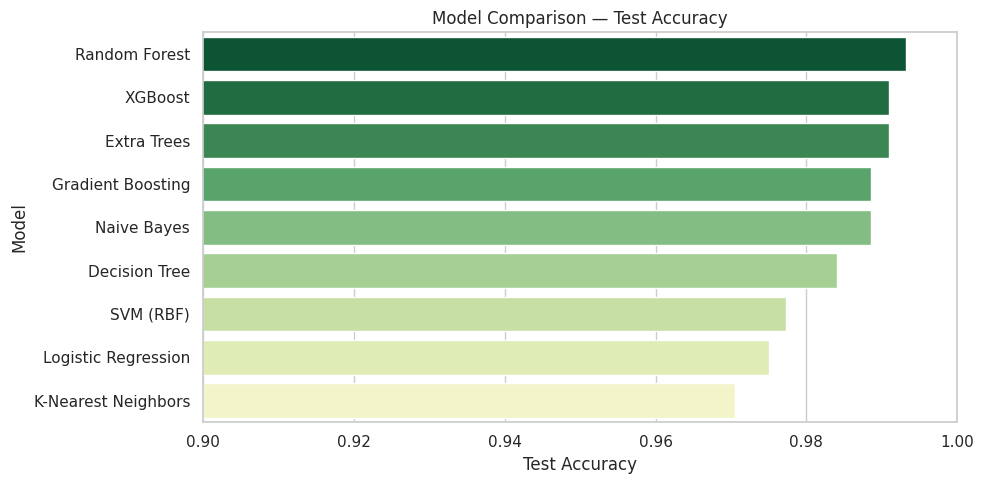

In [5]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Test Accuracy", y="Model", palette="YlGn_r")
plt.xlim(0.9, 1.0)
plt.title("Model Comparison — Test Accuracy")
plt.tight_layout()
plt.savefig("../data/processed/model_comparison.png", dpi=110)
plt.show()

## 13. Hyperparameter Tuning
We fine-tune the top 2 models' settings using grid search because the default settings are rarely the best; small tweaks can meaningfully boost accuracy.

In [6]:
top2 = results_df["Model"].tolist()[:2]
print("Tuning:", top2)
tuned_models = {}

Tuning: ['Random Forest', 'XGBoost']


In [7]:
if "Random Forest" in top2:
    rf_grid = {"n_estimators": [150, 250, 350], "max_depth": [None, 12, 20], "min_samples_split": [2, 4]}
    gs = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_grid, cv=3, scoring="accuracy", n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned_models["Random Forest (Tuned)"] = (gs.best_estimator_, False, gs.best_params_)
    print("Random Forest best params:", gs.best_params_)

Random Forest best params: {'max_depth': 12, 'min_samples_split': 2, 'n_estimators': 250}


In [8]:
if "XGBoost" in top2:
    xgb_grid = {"n_estimators": [150, 250], "max_depth": [4, 6, 8], "learning_rate": [0.05, 0.1, 0.2]}
    gs = GridSearchCV(XGBClassifier(eval_metric="mlogloss", random_state=RANDOM_STATE), xgb_grid, cv=3, scoring="accuracy", n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned_models["XGBoost (Tuned)"] = (gs.best_estimator_, False, gs.best_params_)
    print("XGBoost best params:", gs.best_params_)

XGBoost best params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 150}


In [9]:
if "Extra Trees" in top2:
    et_grid = {"n_estimators": [150, 250, 350], "max_depth": [None, 15, 25]}
    gs = GridSearchCV(ExtraTreesClassifier(random_state=RANDOM_STATE), et_grid, cv=3, scoring="accuracy", n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned_models["Extra Trees (Tuned)"] = (gs.best_estimator_, False, gs.best_params_)
    print("Extra Trees best params:", gs.best_params_)

In [10]:
if "Gradient Boosting" in top2:
    gb_grid = {"n_estimators": [150, 250], "max_depth": [2, 3, 4], "learning_rate": [0.05, 0.1]}
    gs = GridSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE), gb_grid, cv=3, scoring="accuracy", n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned_models["Gradient Boosting (Tuned)"] = (gs.best_estimator_, False, gs.best_params_)
    print("Gradient Boosting best params:", gs.best_params_)

In [11]:
tuned_results = []
for name, (model, needs_scaling, params) in tuned_models.items():
    preds = model.predict(X_test_s if needs_scaling else X_test)
    tuned_results.append({
        "Model": name,
        "Test Accuracy": round(accuracy_score(y_test, preds), 4),
        "F1 Score": round(f1_score(y_test, preds, average="weighted"), 4),
    })
tuned_df = pd.DataFrame(tuned_results).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
tuned_df

,Model,Test Accuracy,F1 Score
0,Random Forest (Tuned),0.9932,0.9932
1,XGBoost (Tuned),0.9886,0.9886


In [12]:
import joblib
joblib.dump(results_df, "../data/processed/_baseline_results.joblib")
joblib.dump(tuned_models, "../data/processed/_tuned_models.joblib")
joblib.dump(tuned_df, "../data/processed/_tuned_results.joblib")
print("Saved comparison + tuning artifacts for the final notebook.")

Saved comparison + tuning artifacts for the final notebook.


## Key takeaways
- Tree-ensemble models (Random Forest, Extra Trees, XGBoost) clearly outperform linear/distance-based models on this dataset.
- Cross-validation confirms the top models generalise consistently (low std across folds).
- Grid search gives a small but real boost over the default-hyperparameter baseline.
- **Next notebook:** `04_final_model_evaluation_conclusion.ipynb` — pick the final model, evaluate it thoroughly, and save it for the Flask app.